In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [3]:
from dcr import * 
data, data_train, _, _, _, _, _ = dataprep(data)

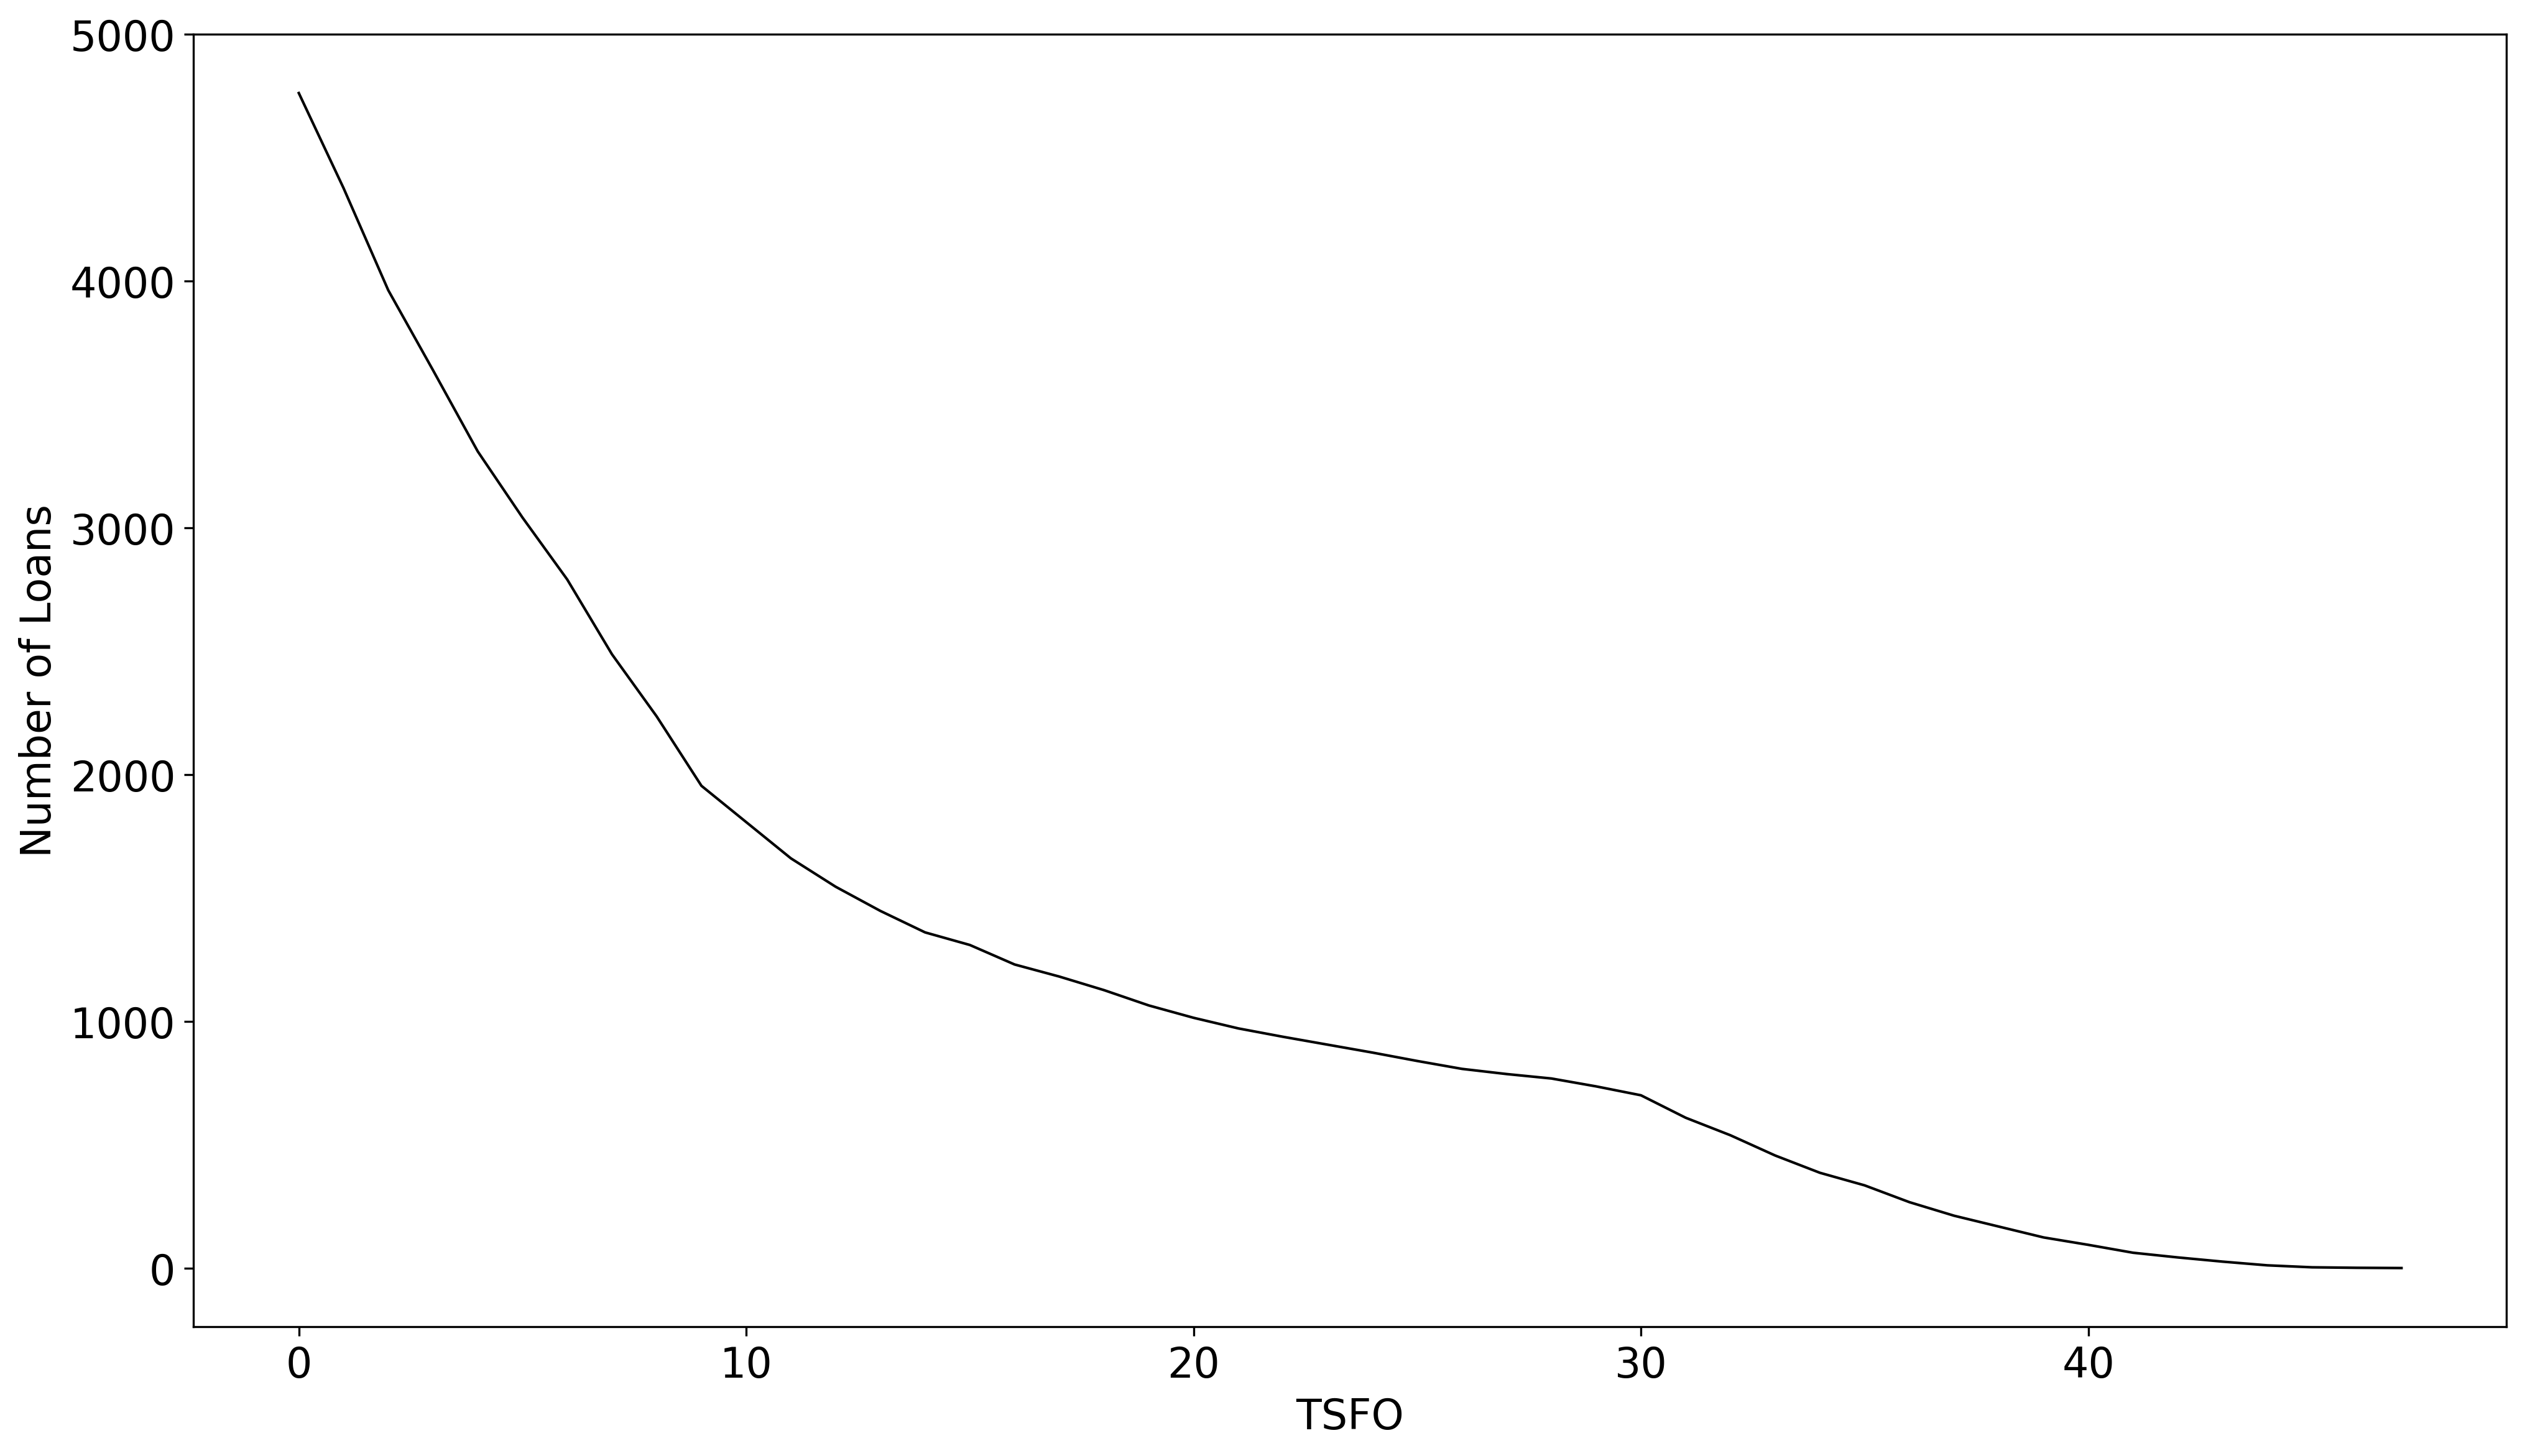

In [4]:
data.loc[:,'TSFO'] = data.loc[:,'time']-data.loc[:,'first_time']  
count = data.groupby(['TSFO'])['id'].count().fillna(0) 

plt.plot(count, marker='', color='black', linewidth=1)  
plt.xlabel('TSFO')
plt.ylabel('Number of Loans')  
plt.show() 

In [5]:
model_lr = smf.glm('payoff_time ~ cep_time + equity_time + interest_rate_time +  FICO_orig_time + gdp_time', family = sm.families.Binomial(), data=data).fit() 
print(model_lr.summary()) 

                 Generalized Linear Model Regression Results                  
Dep. Variable:            payoff_time   No. Observations:                59001
Model:                            GLM   Df Residuals:                    58995
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9981.5
Date:                Sun, 17 Aug 2025   Deviance:                       19963.
Time:                        12:08:39   Pearson chi2:                 5.85e+04
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01562
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -4.8730      0

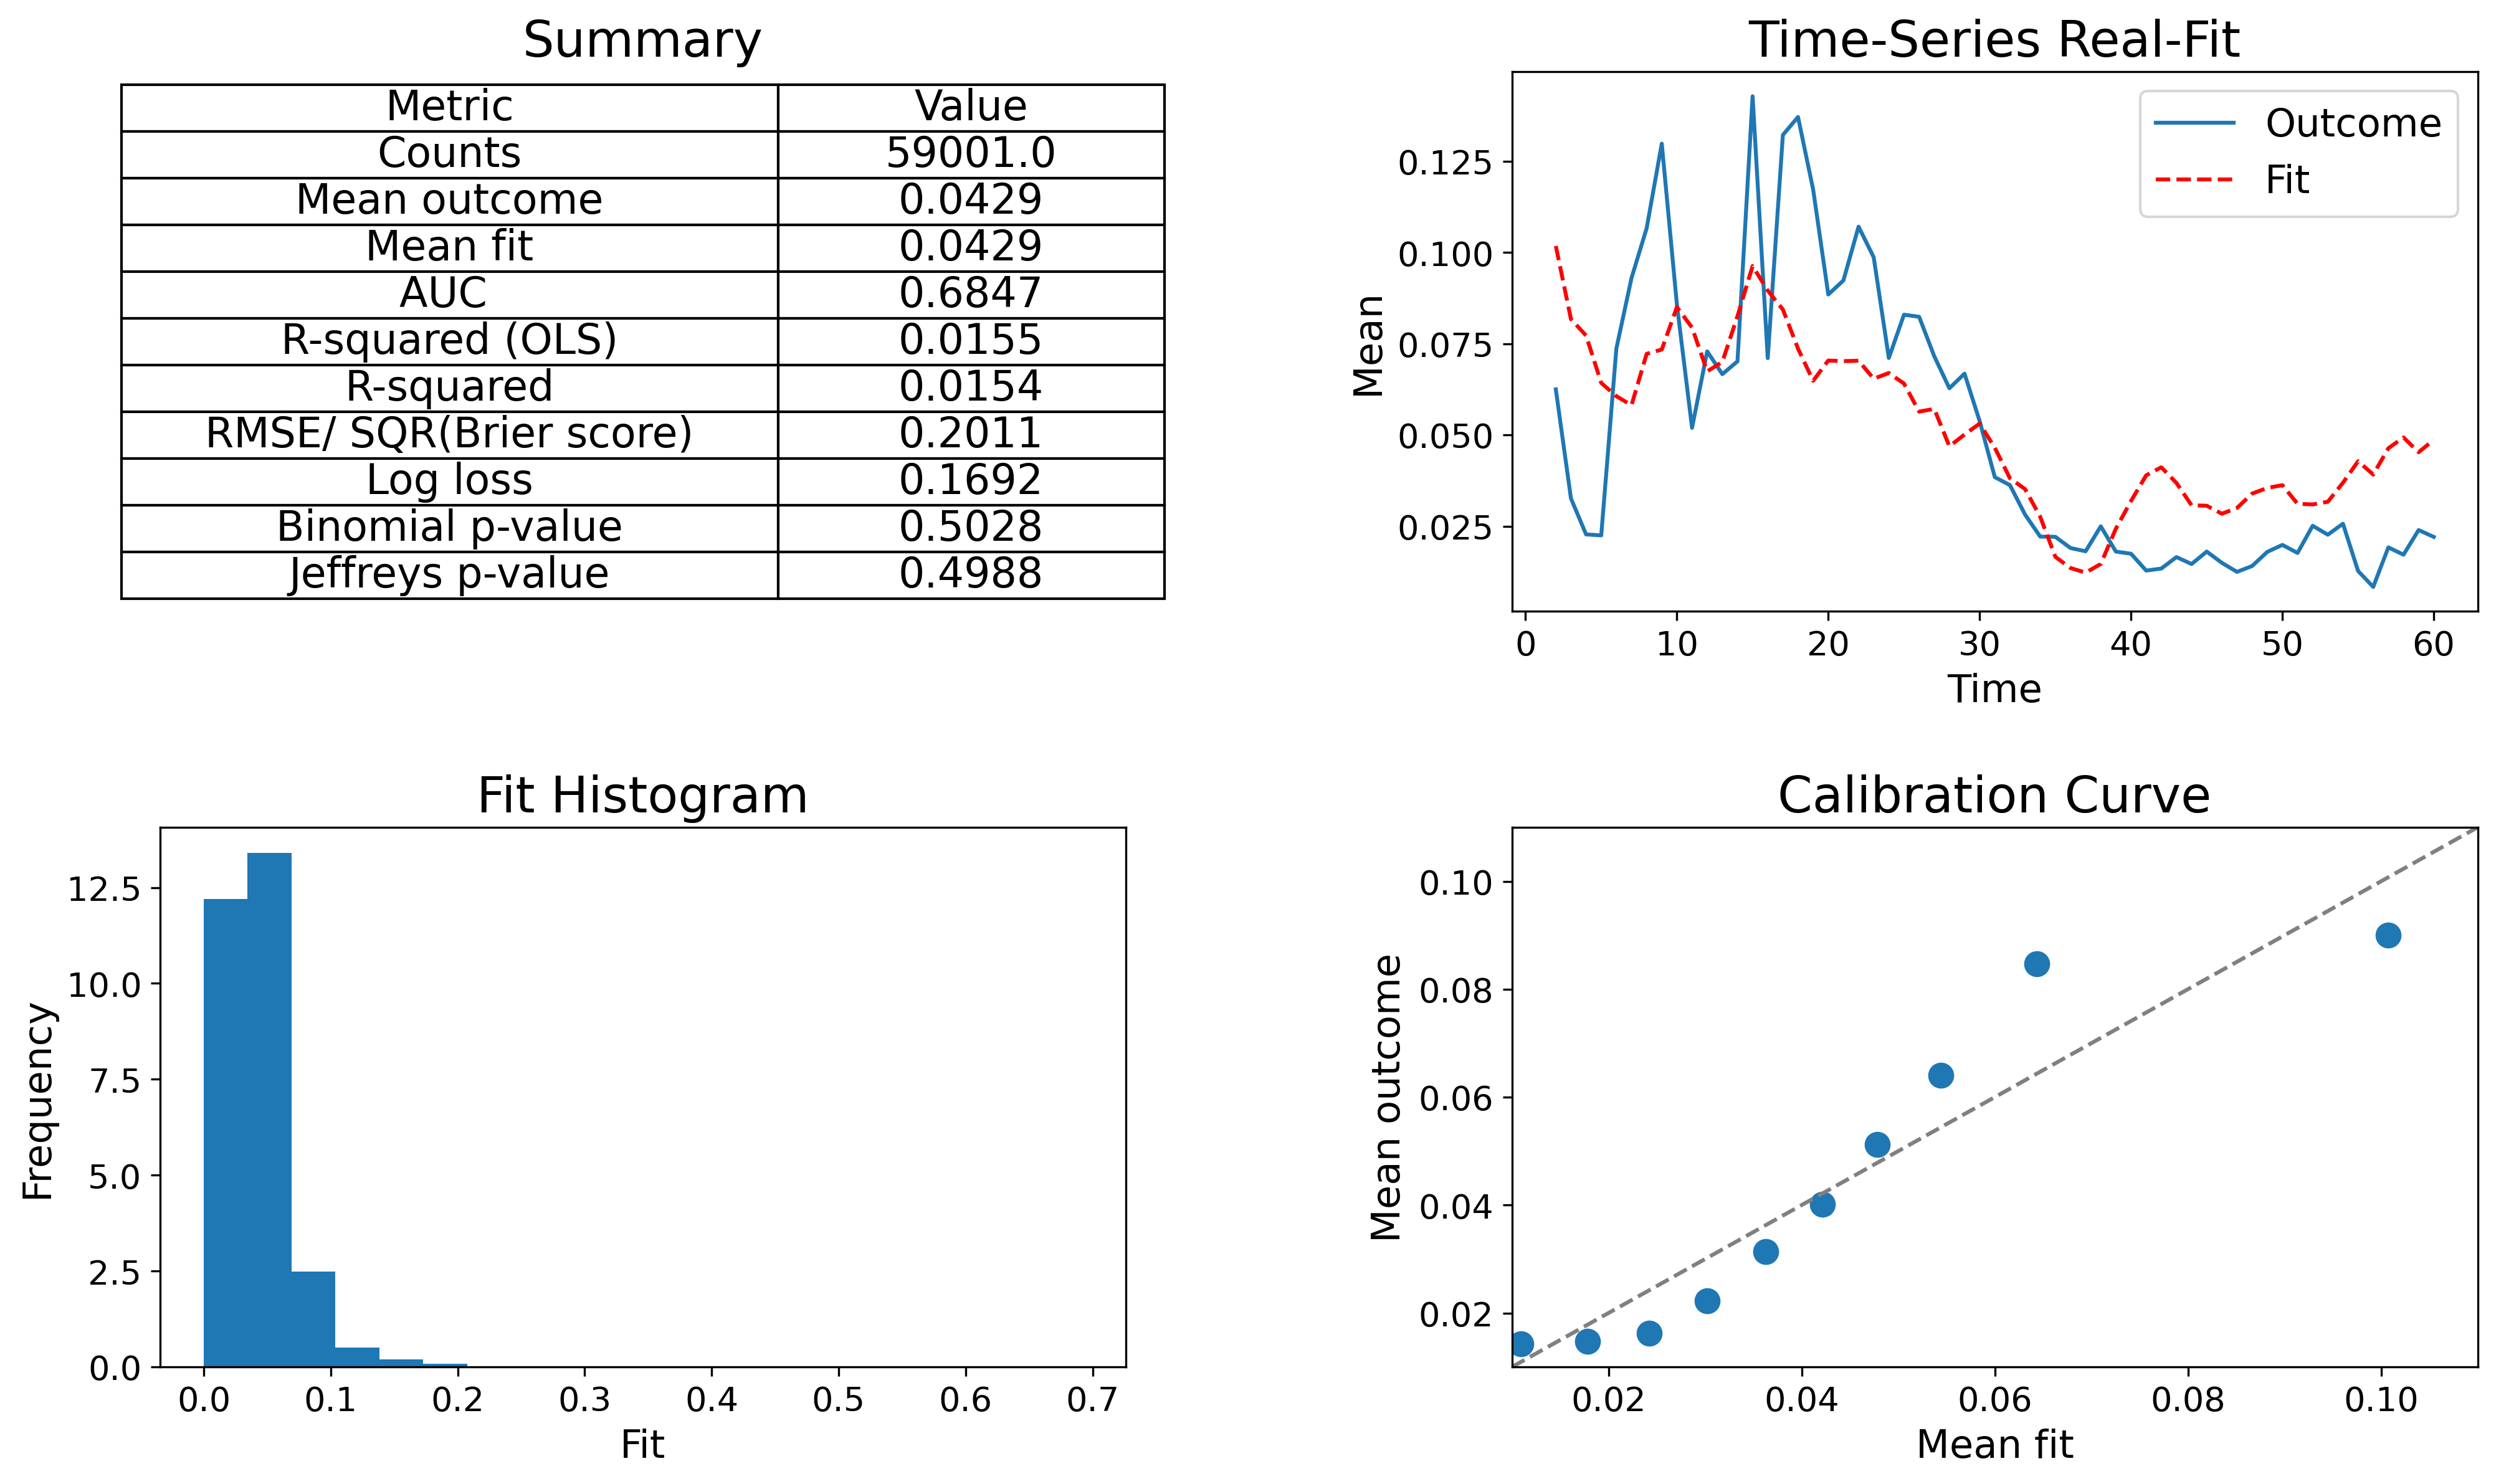

In [6]:
PP_logit_model=pd.DataFrame(model_lr.fittedvalues, columns=['PP_logit_model'])  
data2 = pd.merge(data[['payoff_time','time']], PP_logit_model, right_index=True, left_index  =True)  

validation(data2.PP_logit_model, data2.payoff_time, data2.time)  

In [7]:
data.loc[:,'constant'] = 1 

model_MNL = sm.MNLogit(data[['status_time']],data[['constant', 'cep_time', 'equity_time', 'interest_rate_time', 'FICO_orig_time', 'gdp_time']]).fit()  
print(model_MNL.summary()) 

Optimization terminated successfully.
         Current function value: 0.276926
         Iterations 8
                          MNLogit Regression Results                          
Dep. Variable:            status_time   No. Observations:                59001
Model:                        MNLogit   Df Residuals:                    58989
Method:                           MLE   Df Model:                           10
Date:                Sun, 17 Aug 2025   Pseudo R-squ.:                 0.05296
Time:                        12:08:41   Log-Likelihood:                -16339.
converged:                       True   LL-Null:                       -17253.
Covariance Type:            nonrobust   LLR p-value:                     0.000
     status_time=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
constant              -2.3641      0.337     -7.024      0.000      -3.024      -1.704
cep_t

In [8]:
pred_MNL = model_MNL.predict(data[['constant', 'cep_time', 'equity_time', 'interest_rate_time', 'FICO_orig_time', 'gdp_time']])  
print(pred_MNL.describe().round(decimals=2)) 


              0         1         2
count  59001.00  59001.00  59001.00
mean       0.93      0.02      0.04
std        0.03      0.02      0.03
min        0.14      0.00      0.00
25%        0.92      0.01      0.02
50%        0.94      0.02      0.04
75%        0.95      0.03      0.05
max        1.00      0.48      0.45


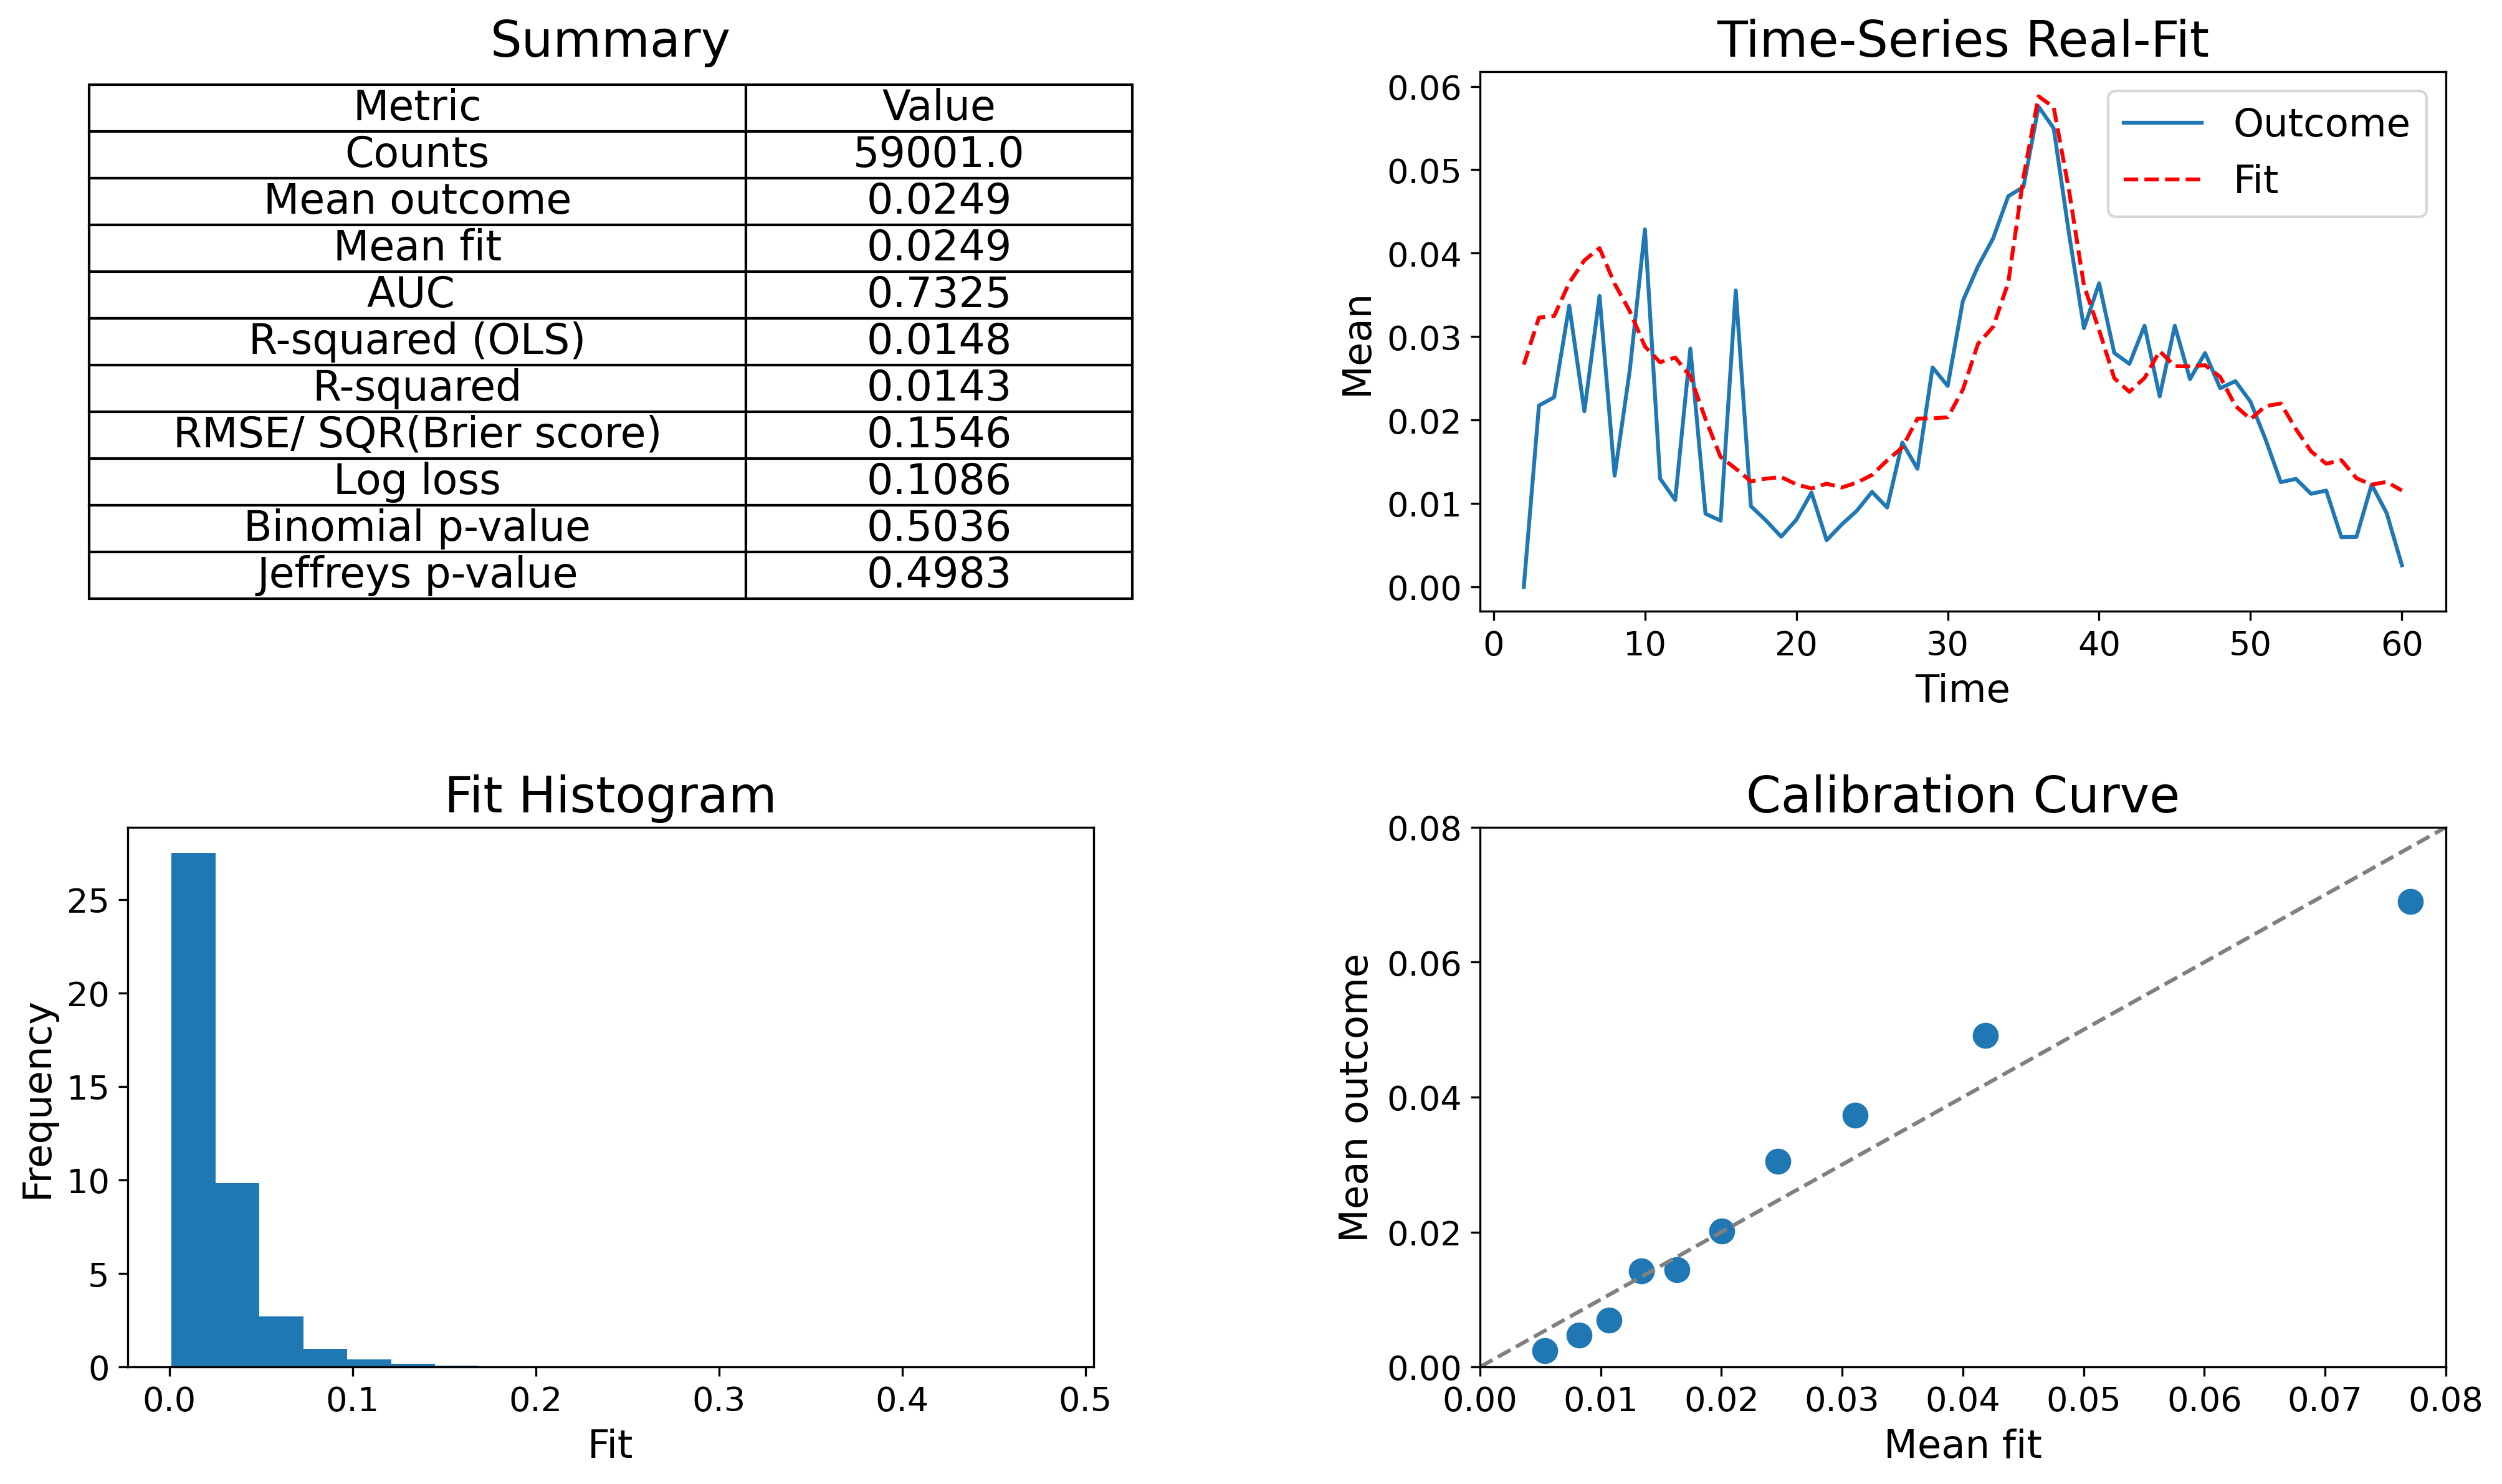

In [9]:
data2 = pd.DataFrame({'time': data.time, 'PD': pred_MNL.loc[:,1], 'PP': pred_MNL.loc[:,2],  'default_time': data.default_time, 'payoff_time': data.payoff_time}) 
validation(data2.PD,data2.default_time,data2.time) 

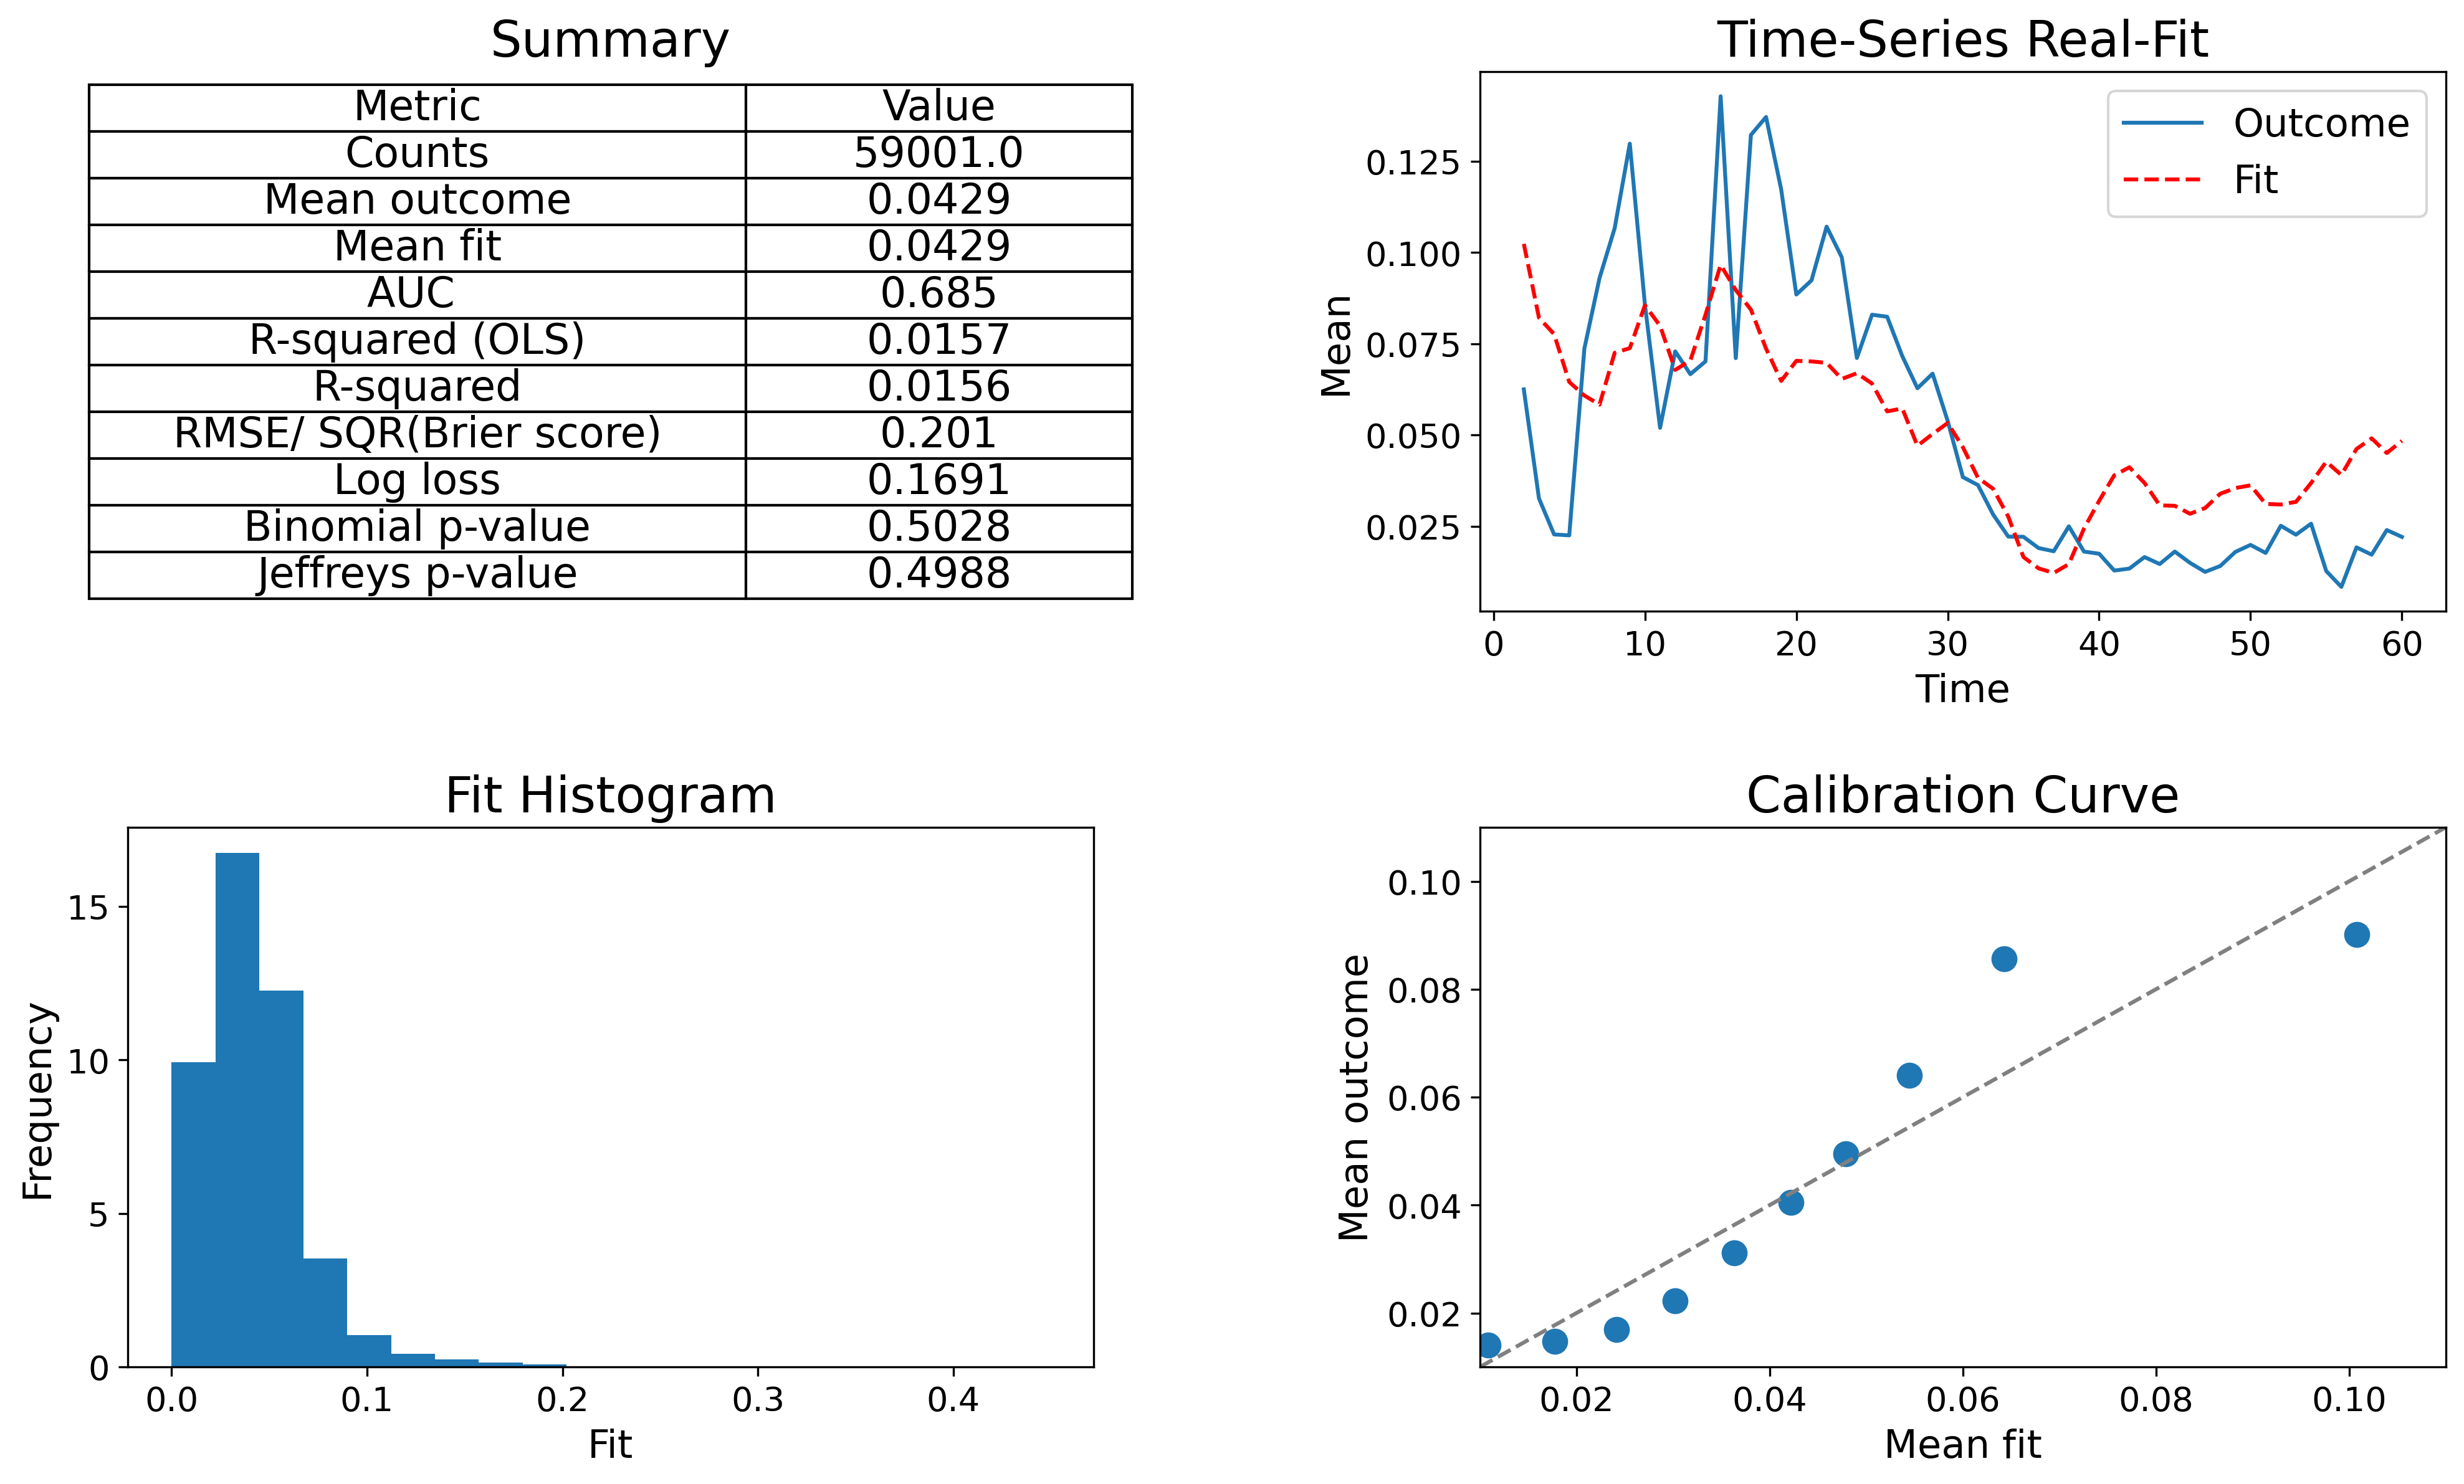

In [10]:
validation(data2.PP, data2.payoff_time, data2.time) 